# Traducción automática con LSTM: implementación desde PyTorch puro

En este notebook vamos a trabajar con el desafío de implementar un sistema de traducción inglés-español utilizando una arquitectura de tipo encoder-decoder basada en LSTM. El objetivo general del trabajo se mantiene alineado con la consigna original: construir un traductor que procese secuencias de entrada en inglés y genere su correspondiente traducción al español.

A lo largo de esta versión, vamos a tomar un enfoque diferente al que fue propuesto originalmente en clase. En lugar de adaptar herramientas de Keras o TensorFlow, optamos por una implementación construida desde cero con PyTorch puro. Esta elección busca reforzar la comprensión detallada de cada componente del modelo, desde la representación de texto hasta la propagación del gradiente.

Se trata de una decisión exploratoria y técnica que apunta a consolidar buenas prácticas en el uso de Pytorch, privilegiando el control sobre cada etapa del proceso y facilitando futuras adaptaciones o extensiones del modelo.

### 1 - Carga y preparación del dataset

En esta sección se carga el archivo spa.txt, que contiene pares de oraciones en inglés y español separadas por tabulaciones. Dado que contamos con suficiente memoria disponible, se trabajará con todo el dataset sin aplicar restricciones artificiales en la cantidad de ejemplos leídos.

Cada línea se divide en tres representaciones:
- input_sentence: oración de entrada en inglés (usada por el encoder)
- output_sentence: oración objetivo en español con token <eos> al final (usada como etiqueta esperada del decoder)
- output_sentence_input: oración en español con token <sos> al inicio (usada como entrada al decoder durante el entrenamiento con teacher forcing)

In [246]:
import numpy as np

from pathlib import Path
from typing import Tuple, List


def load_translation_pairs(file_path: str, seed: int = 40) -> Tuple[List[str], List[str], List[str]]:
    """
    Carga oraciones paralelas inglés-español desde un archivo .txt en formato tabulado. Cabe mencionar
    que los tokens <sos> y <eos> no se agregan en esta función, sino que se deben agregar una vez 
    creados los vocabularios.

    :param file_path: Ruta al archivo .txt con pares de oraciones tabuladas
    :param seed: Semilla para mezcla aleatoria reproducible
    :return: Tupla con listas: input_sentences (inglés), output_sentences (español), output_sentences_inputs (español)
    """
    path = Path(file_path)
    assert path.exists(), f'El archivo {file_path} no existe.'

    with open(path, encoding='utf-8') as f:
        lines = [line.strip() for line in f if '\t' in line]

    np.random.seed(seed)
    np.random.shuffle(lines)

    input_sentences = []
    output_sentences = []
    output_sentences_inputs = []

    # <sos> y <eos> se agregarán luego de generar los vocabularios
    for line in lines:
        input_sentence, output = line.split('\t')
        input_sentences.append(input_sentence)
        output_sentences.append(output)
        output_sentences_inputs.append(output)

    return input_sentences, output_sentences, output_sentences_inputs

# Uso
text_file = './spa-eng/spa.txt'
input_sentences, output_sentences, output_sentences_inputs = load_translation_pairs(text_file)

print(f'Cantidad de pares cargados: {len(input_sentences)}')
print('Ejemplo:')
print(f'\tEN: {input_sentences[0]}')
print(f'\tES target: {output_sentences[0]}')
print(f'\tES input:  {output_sentences_inputs[0]}')


Cantidad de pares cargados: 118964
Ejemplo:
	EN: Somebody stole my car.
	ES target: Alguien robó mi auto.
	ES input:  Alguien robó mi auto.


### 2 - Preprocesamiento de los datos

Antes de construir el vocabulario del modelo, se realiza un análisis de cobertura para estimar cuántas palabras del corpus total están representadas por los N tokens más frecuentes. El objetivo es encontrar un buen balance entre eficiencia computacional y riqueza lingüística.

In [247]:
unique_words_es = set()
for sentence in output_sentences:
    unique_words_es.update(sentence.split())
print(f'Cantidad de palabras únicas en español: {len(unique_words_es)}')

unique_words_en = set()
for sentence in input_sentences:
    unique_words_en.update(sentence.split())
print(f'Cantidad de palabras únicas en inglés: {len(unique_words_en)}')

Cantidad de palabras únicas en español: 44585
Cantidad de palabras únicas en inglés: 25512


In [248]:
print(list(unique_words_en)[0:10])  # Mostrar las primeras 10 palabras únicas en inglés
print(list(unique_words_es)[0:10])  # Mostrar las primeras 10 palabras únicas en español

['bicycle', 'simmer', 'attendant', 'detests', 'April.', 'opposition.', 'sobbing', 'cupboard?', 'surged', 'forthcoming.']
['más,', 'casadas.', 'dependemos', 'cree.', 'aliviará', 'tenis?"', 'grosera.', 'Métete', 'Doy', 'pétalos']


In [249]:
from collections import Counter

def coverage(corpus: list[str], vocab_size: int) -> float:
    words = [w for sent in corpus for w in sent.lower().split()]
    total = len(words)
    freq = Counter(words)
    most_common = freq.most_common(vocab_size)
    covered = sum(count for _, count in most_common)
    return covered / total

coverage_en = coverage(input_sentences, 8000)
coverage_en_30k = coverage(input_sentences, 20000)
print(f'Cobertura en inglés con tamaño de vocabulario de 8000: {coverage_en:.2%}')
print(f'Cobertura en inglés con tamaño de vocabulario de 20000: {coverage_en_30k:.2%}')

coverage_es = coverage(output_sentences, 8000)
coverage_es_30k = coverage(output_sentences, 30000)
print(f'Cobertura en español con tamaño de vocabulario de 8000: {coverage_es:.2%}')
print(f'Cobertura en español con tamaño de vocabulario de 30000: {coverage_es_30k:.2%}\n')

Cobertura en inglés con tamaño de vocabulario de 8000: 96.51%
Cobertura en inglés con tamaño de vocabulario de 20000: 99.49%
Cobertura en español con tamaño de vocabulario de 8000: 91.50%
Cobertura en español con tamaño de vocabulario de 30000: 98.38%



Como puede observarse, los resultados obtenidos fueron:

- Cobertura en español con tamaño de vocabulario de 8000: 91.50%
- Cobertura en español con tamaño de vocabulario de 30000: 98.38%

- Cobertura en inglés con tamaño de vocabulario de 8000: 96.51%
- Cobertura en inglés con tamaño de vocabulario de 20000: 99.49%

Esto nos indica que, si bien un vocabulario reducido de 8000 palabras ya cubre una porción significativa del corpus, aún deja fuera un porcentaje no menor de tokens relevantes, especialmente en español.

Dado que se disponen recursos de hardware suficientes (32 GB de RAM y 6 GB de VRAM), se opta por:

- Un vocabulario de 20.000 palabras para inglés
- Un vocabulario de 30.000 palabras para español

Esta elección mejora la cobertura sin comprometer la viabilidad del entrenamiento, y permite al modelo manejar una mayor diversidad léxica durante la generación de traducciones.

In [250]:
from collections import Counter
from typing import List

class Vocab:
    """
    Clase para mapear palabras a índices y viceversa, con soporte para tokens especiales y limpieza configurable.
    """
    def __init__(
        self,
        texts: List[str],
        max_vocab_size: int,
        filters: str = '!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n',
        specials: Tuple[str, ...] = ('<pad>', '<sos>', '<eos>', '<unk>')
    ):
        self.filters = filters
        self.special_tokens = specials
        self.word_freq = Counter()

        for text in texts:
            clean = self._clean_text(text.lower())
            self.word_freq.update(clean.split())

        # Vocabulario limitado a max_vocab_size incluyendo los tokens especiales
        most_common = list(self.special_tokens) + [w for w, _ in self.word_freq.most_common(max_vocab_size - len(self.special_tokens))]
        self.word2idx = {w: i for i, w in enumerate(most_common)}
        self.idx2word = {i: w for w, i in self.word2idx.items()}

        self.pad_idx = self.word2idx['<pad>']
        self.sos_idx = self.word2idx.get('<sos>')
        self.eos_idx = self.word2idx.get('<eos>')
        self.unk_idx = self.word2idx['<unk>']

    def _clean_text(self, text: str) -> str:
        return text.translate(str.maketrans({c: ' ' for c in self.filters}))

    def text_to_sequence(self, text: str) -> List[int]:
        clean = self._clean_text(text.lower())
        return [self.word2idx.get(word, self.unk_idx) for word in clean.split()]

    def sequence_to_text(self, sequence: List[int]) -> str:
        return ' '.join([self.idx2word.get(idx, '<unk>') for idx in sequence])

    def __len__(self):
        return len(self.word2idx)


In [251]:
# Parámetros definidos con base en análisis de cobertura
MAX_VOCAB_INPUT = 20000
MAX_VOCAB_OUTPUT = 30000

# Construcción del vocabulario inglés
input_vocab = Vocab(input_sentences, max_vocab_size=MAX_VOCAB_INPUT)

# Construcción del vocabulario español
output_vocab = Vocab(output_sentences, max_vocab_size=MAX_VOCAB_OUTPUT)

# Se agregan los tokens <sos> y <eos> a las oraciones de salida
output_sentences = [s + ' <eos>' for s in output_sentences]
output_sentences_inputs = ['<sos> ' + s for s in output_sentences_inputs]

# Ejemplo de uso del vocabulario
print(f'Cantidad de palabras en vocabulario inglés: {len(input_vocab)}')
print(f'Cantidad de palabras en vocabulario español: {len(output_vocab)}')

Cantidad de palabras en vocabulario inglés: 13528
Cantidad de palabras en vocabulario español: 26342


Al construir los vocabularios para inglés y español, se observa que el número de palabras únicas finales es sensiblemente menor que el total de palabras distintas originalmente presentes en el corpus. Por ejemplo:

- Palabras únicas originales en español: 44.585  
- Palabras en vocabulario final (tras limpieza y truncamiento): 26.342

- Palabras únicas originales en inglés: 25.512  
- Palabras en vocabulario final (tras limpieza y truncamiento): 13.528  

Esta reducción se explica por dos factores:

1. Limpieza de texto:  
   Al tokenizar, se eliminaron símbolos de puntuación y caracteres especiales (como '¿', '.', '!', '"', etc.) definidos en la variable filters. Esto hace que tokens que originalmente se consideraban distintos pasen a tener la misma forma una vez limpios.  
   Por ejemplo, 'Hola.' y 'Hola' pasan a ser el mismo token: 'hola'.

2. Tope de tamaño de vocabulario:
   Aunque originalmente se permitía un máximo de 20.000 palabras para inglés y 30.000 para español, no fue necesario usar ese límite, ya que el corpus ya reducido por limpieza no contenía tantas palabras distintas después del filtrado.

En resumen, esta reducción es esperada y deseada: ayuda a consolidar variantes de una misma palabra que solo difieren por puntuación, y mejora la generalización del modelo al enfocarse en las palabras más frecuentes del corpus.

In [252]:
# Mapear cada oración a secuencia de índices
input_seqs = [input_vocab.text_to_sequence(s) for s in input_sentences]
output_seqs = [output_vocab.text_to_sequence(s) for s in output_sentences]
output_input_seqs = [
    output_vocab.text_to_sequence(s) for s in output_sentences_inputs
]

In [253]:
print('Ejemplo de tokenización y reconstrucción:')
print('Original:', input_sentences[0])
print('Tokenizado:', input_vocab.text_to_sequence(input_sentences[0]))
print('Reconstruido:', input_vocab.sequence_to_text(
    input_vocab.text_to_sequence(input_sentences[0]))
)

Ejemplo de tokenización y reconstrucción:
Original: Somebody stole my car.
Tokenizado: [769, 1186, 21, 108]
Reconstruido: somebody stole my car


Para poder procesar los datos en lotes (batching) y alimentar correctamente las redes LSTM, es necesario que todas las secuencias tengan la misma longitud. Sin embargo, las oraciones reales tienen longitudes variables.

La solución común es aplicar padding, es decir, completar las secuencias más cortas con un token especial <pad> hasta alcanzar una longitud fija.

A la hora de realiza padding es importante tener en cuenta que en el encoder los ceros se agregan al comienzo y en el decoder al final. Esto es porque la salida del encoder está basado en las últimas palabras de la sentencia (son las más importantes), mientras que en el decoder está basado en el comienzo de la secuencia de salida ya que es la realimentación del sistema y termina con fin de sentencia.

El valor de padding es el índice asignado a <pad> en cada vocabulario.

In [254]:
import torch

from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence

def pad_sequences(sequences: list[list[int]], max_len: int, padding_value: int = 0, padding: str = 'post') -> torch.Tensor:
    """
    Aplica padding a una lista de secuencias de enteros.

    :param sequences: Lista de secuencias (listas de enteros)
    :param max_len: Largo máximo de la secuencia tras padding/truncado
    :param padding_value: Valor de padding (default 0)
    :param padding: 'pre' o 'post' padding (default 'post')
    :return: Tensor shape (batch_size, max_len)
    """
    tensor_seqs = []
    for seq in sequences:
        seq_tensor = torch.tensor(seq[:max_len])
        if padding == 'post':
            padded = F.pad(seq_tensor, (0, max_len - len(seq_tensor)), value=padding_value)
        elif padding == 'pre':
            padded = F.pad(seq_tensor, (max_len - len(seq_tensor), 0), value=padding_value)
        else:
            raise ValueError("padding must be 'pre' or 'post'")
        tensor_seqs.append(padded)
    return torch.stack(tensor_seqs)


In [255]:
input_lens = [len(seq) for seq in input_seqs]
output_lens = [len(seq) for seq in output_seqs]

max_input_idx = np.argmax(input_lens)
max_output_idx = np.argmax(output_lens)

print(f'Longitud máxima de secuencia en inglés: {input_lens[max_input_idx]}')
print(f'Oración original (inglés):\n{input_sentences[max_input_idx]}\n')

print(f'Longitud máxima de secuencia en español: {output_lens[max_output_idx]}')
print(f'Oración original (español):\n{output_sentences[max_output_idx]}\n')

print('Tamaño de sentencia en inglés según percentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  P{p}: {np.percentile(input_lens, p)} tokens')

print('\nTamaño de sentencia en español según percentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  P{p}: {np.percentile(output_lens, p)} tokens')

Longitud máxima de secuencia en inglés: 47
Oración original (inglés):
If you want to sound like a native speaker, you must be willing to practice saying the same sentence over and over in the same way that banjo players practice the same phrase over and over until they can play it correctly and at the desired tempo.

Longitud máxima de secuencia en español: 50
Oración original (español):
Si quieres sonar como un hablante nativo, debes estar dispuesto a practicar diciendo la misma frase una y otra vez de la misma manera en que un músico de banjo practica el mismo fraseo una y otra vez hasta que lo puedan tocar correctamente y en el tiempo esperado. <eos>

Tamaño de sentencia en inglés según percentiles:
  P50: 6.0 tokens
  P75: 8.0 tokens
  P90: 10.0 tokens
  P95: 11.0 tokens
  P99: 14.0 tokens

Tamaño de sentencia en español según percentiles:
  P50: 7.0 tokens
  P75: 8.0 tokens
  P90: 11.0 tokens
  P95: 12.0 tokens
  P99: 16.0 tokens


Las oraciones reales tienen longitudes variables. Para poder procesarlas en lotes de tamaño fijo, se define una longitud máxima (max_len) para cada tipo de secuencia, y se aplica truncado o padding según corresponda.

Para seleccionar valores razonables, se analizó la distribución de longitudes de las secuencias en inglés (entrada al encoder) y español (salida del decoder). Los resultados fueron:

- En inglés:
  - P95: 11 tokens
  - P99: 14 tokens
  - Longitud máxima: 47 tokens

- En español:
  - P95: 12 tokens
  - P99: 16 tokens
  - Longitud máxima: 50 tokens

Esto indica que la mayoría de las oraciones son cortas, pero existen algunos outliers mucho más largos. Para balancear eficiencia computacional y cobertura del corpus, se decidió truncar las secuencias en:

- max_len_input = 16 (inglés)
- max_len_output = 18 (español)

Con estos valores se asegura cubrir más del 99% del corpus sin truncar contenido relevante, manteniendo al mismo tiempo tensores compactos que aceleran el entrenamiento y reducen el consumo de memoria.

In [256]:
MAX_LEN_INPUT = 16
MAX_LEN_OUTPUT = 18

In [257]:
encoder_input_tensor = pad_sequences(input_seqs, max_len=MAX_LEN_INPUT, padding_value=input_vocab.pad_idx, padding='pre')
decoder_input_tensor = pad_sequences(output_input_seqs, max_len=MAX_LEN_OUTPUT, padding_value=output_vocab.pad_idx, padding='post')
decoder_target_tensor = pad_sequences(output_seqs, max_len=MAX_LEN_OUTPUT, padding_value=output_vocab.pad_idx, padding='post')

In [258]:
print(f'Tamaño de entrada del encoder: {encoder_input_tensor.shape}')
print(f'Tamaño de entrada del decoder: {decoder_input_tensor.shape}')
print(f'Dimensión de salida del decoder: {decoder_target_tensor.shape}')

Tamaño de entrada del encoder: torch.Size([118964, 16])
Tamaño de entrada del decoder: torch.Size([118964, 18])
Dimensión de salida del decoder: torch.Size([118964, 18])


Con las secuencias tokenizadas, convertidas a índices y paddeadas, se construye un Dataset personalizado de PyTorch para encapsular los tres componentes de cada muestra:

- encoder_input: secuencia en inglés, de longitud fija, con padding al inicio
- decoder_input: secuencia en español comenzando con <sos>, con padding al final
- decoder_target: secuencia en español terminando en <eos>, también con padding al final

Estos elementos se devuelven mediante el método __getitem__ del Dataset, y luego se utilizan por los DataLoaders de entrenamiento y validación.

Se utiliza una división estratificada simple:
- 80% de los datos para entrenamiento
- 20% para validación

Los DataLoaders permitirán trabajar en batches de tamaño fijo, barajando los datos durante el entrenamiento para mejorar la generalización.


In [259]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    """
    Dataset personalizado para tareas de traducción.
    """
    def __init__(self, encoder_input, decoder_input, decoder_target):
        self.encoder_input = encoder_input
        self.decoder_input = decoder_input
        self.decoder_target = decoder_target

    def __len__(self):
        return len(self.encoder_input)

    def __getitem__(self, idx):
        return (
            self.encoder_input[idx],
            self.decoder_input[idx],
            self.decoder_target[idx],
        )

In [260]:
from torch.utils.data import random_split, DataLoader

# Creamos el dataset completo
dataset = TranslationDataset(encoder_input_tensor, decoder_input_tensor, decoder_target_tensor)

# División 80/20
train_size = int(0.8 * len(dataset))
valid_size = len(dataset) - train_size
torch.manual_seed(42)
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

# DataLoaders
BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [261]:
print(f'Tamaño del dataset de entrenamiento: {len(train_dataset)}')
print(f'Tamaño del dataset de validación: {len(valid_dataset)}')

Tamaño del dataset de entrenamiento: 95171
Tamaño del dataset de validación: 23793


### 3 - Modelo de embeddings

Para representar las palabras como vectores densos, se utilizarán embeddings preentrenados GloVe de 50 dimensiones, específicamente los entrenados sobre 2 mil millones de tweets y un vocabulario de 1.2 millones de palabras.

Se opta por usar la versión de 50 dimensiones (glove.twitter.27B.50d.txt) por dos razones principales:
- Su menor dimensión permite un entrenamiento más eficiente sin perder expresividad para frases cortas.
- Fue entrenado con datos conversacionales (tweets), lo que es adecuado para muchas de las frases cotidianas del corpus.

No se utilizará un archivo pickle preprocesado. En su lugar:
- Se cargará directamente el archivo .txt con los vectores.
- Se filtrarán las palabras para conservar únicamente aquellas que están presentes en nuestro vocabulario (input_vocab).
- Se construirá una matriz de embeddings (embedding_matrix) que podrá inicializar la capa nn.Embedding del modelo encoder.

Esto mejora la eficiencia al evitar cargar embeddings innecesarios y mantiene una total trazabilidad del proceso.

In [262]:
import torch
import numpy as np
import torch.nn as nn

def load_glove_embeddings(glove_path: str, vocab: Vocab, embedding_dim: int = 50) -> np.ndarray:
    """
    Carga embeddings GloVe desde un archivo .txt, filtrando sólo las palabras presentes en el vocabulario.

    :param glove_path: Ruta al archivo GloVe (ej. glove.twitter.27B.50d.txt)
    :param vocab: Instancia de la clase Vocab
    :param embedding_dim: Dimensión del vector embedding (ej. 50)
    :return: Matriz de embeddings de forma (vocab_size, embedding_dim)
    """
    embeddings_index = {}

    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            if word in vocab.word2idx:
                vector = np.asarray(values[1:], dtype='float32')
                if len(vector) == embedding_dim:
                    embeddings_index[word] = vector

    vocab_size = len(vocab)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype='float32')

    words_not_found = []
    for word, idx in vocab.word2idx.items():
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
        else:
            words_not_found.append(word)

    print(f'Palabras no encontradas en GloVe: {len(words_not_found)} de {vocab_size}')
    return embedding_matrix

In [278]:
import os

def download_glove_twitter_embeddings():
    # Ruta del archivo específico que se quiere verificar
    glove_file = './embeddings/glove.twitter.27B.50d.txt'
    
    if os.path.exists(glove_file):
        print(f'El archivo ya existe en: {glove_file}')
        return

    # Instalamos gdown si no está instalado
    try:
        import gdown
    except ImportError:
        print('Instalando gdown...')
        os.system('pip install -q gdown')
        import gdown

    # URL pública de la carpeta
    folder_url = 'https://drive.google.com/drive/folders/1wKc-4BGTpkVj5B3iYI5e4A8B967u2poa'
    output_dir = './embeddings'

    print(f'Descargando embeddings desde Google Drive a: {output_dir}')
    gdown.download_folder(url=folder_url, output=output_dir, quiet=False, use_cookies=False)

    if os.path.exists(glove_file):
        print(f'Descarga completada. Archivo disponible en: {glove_file}')
    else:
        print(f'Descarga finalizada, pero el archivo {glove_file} no se encontró. Verificar manualmente.')

# Ejecutar
download_glove_twitter_embeddings()

Descargando embeddings desde Google Drive a: ./embeddings


Retrieving folder contents


Processing file 1P1oVBqEEaDxla5BT-iZM8QbDSrt3FdRY glove.twitter.27B.50d.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1P1oVBqEEaDxla5BT-iZM8QbDSrt3FdRY
From (redirected): https://drive.google.com/uc?id=1P1oVBqEEaDxla5BT-iZM8QbDSrt3FdRY&confirm=t&uuid=f360774f-0362-45ee-9c9e-4a701030ee49
To: /home/pidg64/Dev/CEIA/PLN/ceia-18co2024-pln/Desafio 4/embeddings/glove.twitter.27B.50d.txt
100%|██████████| 511M/511M [00:18<00:00, 27.3MB/s] 

Descarga completada. Archivo disponible en: ./embeddings/glove.twitter.27B.50d.txt



Download completed


In [264]:
embedding_matrix = torch.tensor(load_glove_embeddings('./embeddings/glove.twitter.27B.50d.txt', input_vocab, embedding_dim=50), dtype=torch.float32)

embedding_layer = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)  # congelar para no entrenar embeddings

Palabras no encontradas en GloVe: 827 de 13528


La matriz de embeddings se construyó filtrando únicamente las palabras presentes en el vocabulario del encoder (input_vocab), evitando cargar el archivo completo en memoria y reduciendo el tamaño final del modelo.

Para el decoder, en cambio, se construirá una capa de embeddings entrenable desde cero, ya que:
- No se cuenta con un modelo preentrenado equivalente en español.
- El decoder aprende durante el entrenamiento a representar adecuadamente las palabras que genera, en base al feedback de la función de pérdida.

### 4 - Modelos

Con los datos ya preprocesados y los embeddings preparados, pasamos ahora al armado del modelo principal: una arquitectura encoder-decoder basada en LSTM, que será responsable de realizar la traducción secuencial de inglés a español.

El modelo estará compuesto por tres bloques principales:

- Encoder: una red LSTM que recibe las secuencias en inglés tokenizadas. Su tarea es codificar la oración de entrada en un vector de estado oculto y de memoria (hidden, cell) que resume su contenido semántico.
- Decoder: otra red LSTM que, a partir del estado generado por el encoder, genera una secuencia en español palabra por palabra. En el entrenamiento, recibirá también como entrada la secuencia objetivo desplazada (teacher forcing).
- Capa final (linear + softmax): toma la salida del decoder en cada paso y la proyecta al tamaño del vocabulario en español, produciendo una distribución de probabilidad sobre las posibles palabras a generar.

Este tipo de arquitectura es la base de los traductores neuronales y permite entrenar modelos end-to-end que aprenden directamente la correspondencia entre frases de diferentes idiomas.

En esta implementación:
- Se reutilizarán los embeddings de GloVe (preentrenados) para el encoder.
- Los embeddings del decoder serán entrenables desde cero.

A continuación, se implementarán los bloques Encoder, Decoder y Seq2Seq como módulos separados de PyTorch.


In [265]:
from torch import nn


class Encoder(nn.Module):
    """
    Codificador LSTM para la secuencia en idioma origen (inglés).
    Utiliza embeddings preentrenados (GloVe) que no se actualizan durante el entrenamiento.
    """

    def __init__(
        self,
        input_vocab_size: int,
        embedding_dim: int,
        hidden_size: int,
        num_layers: int = 1,
        dropout: float = 0.1,
        embedding_weights: torch.Tensor = None
    ):
        super().__init__()

        self.embedding = nn.Embedding(input_vocab_size, embedding_dim, padding_idx=0)

        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)
            self.embedding.weight.requires_grad = False  # Congelar GloVe

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """
        :param x: Tensor de entrada (batch_size, seq_len)
        :return: outputs (batch_size, seq_len, hidden_size),
            (h_n, c_n): estados finales de LSTM
        """
        embedded = self.embedding(x)
        outputs, (h_n, c_n) = self.lstm(embedded)
        return outputs, (h_n, c_n)


In [266]:
import torch
import torch.nn as nn

from typing import Tuple


class Decoder(nn.Module):
    """
    Decoder LSTM para generar texto en el idioma destino (español).
    Usa una capa de embedding entrenable y predice distribuciones sobre el vocabulario de salida.
    """
    
    def __init__(
        self,
        output_vocab_size: int,
        embedding_dim: int,
        hidden_size: int,
        num_layers: int = 1,
        dropout: float = 0.1
    ):
        super().__init__()
        self.embedding = nn.Embedding(output_vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc_out = nn.Linear(hidden_size, output_vocab_size)

    def forward(
        self,
        x: torch.Tensor,
        hidden: Tuple[torch.Tensor, torch.Tensor]
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        :param x: (batch_size, 1) índice del token actual
        :param hidden: estados previos del decoder (h_n, c_n)
        :return: logits (batch_size, output_vocab_size), hidden
        """
        embedded = self.embedding(x)  # (batch_size, 1, embedding_dim)
        output, hidden = self.lstm(embedded, hidden)  # output: (batch_size, 1, hidden_size)
        logits = self.fc_out(output.squeeze(1))  # (batch_size, output_vocab_size)
        return logits, hidden


In [267]:
class Seq2Seq(nn.Module):
    """
    Wrapper que conecta encoder y decoder para traducción.
    Implementa teacher forcing durante el entrenamiento.
    """
    
    def __init__(
        self,
        encoder: Encoder,
        decoder: Decoder,
        device: torch.device
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        src: torch.Tensor,
        trg: torch.Tensor,
        teacher_forcing_ratio: float = 1.0
    ) -> torch.Tensor:
        """
        :param src: (batch_size, src_len)
        :param trg: (batch_size, trg_len)
        :param teacher_forcing_ratio: probabilidad de usar el token real como input del decoder
        :return: logits (batch_size, trg_len, output_vocab_size)
        """
        batch_size = src.size(0)
        trg_len = trg.size(1)
        output_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, trg_len, output_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input_token = trg[:, 0].unsqueeze(1)  # primer token <sos>
        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = output
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1
        return outputs


### 5 - Creación de la arquitectura

En esta etapa se instancia el modelo encoder-decoder completo, compuesto por dos redes LSTM independientes:

- Encoder: procesa la secuencia en idioma fuente (inglés) y devuelve un estado oculto final que resume el contenido.
- Decoder: genera la secuencia traducida (español) palabra por palabra, condicionado al estado del encoder.

Componentes principales

- Embedding Layer:
  - El encoder usa embeddings preentrenados (GloVe de 50 dimensiones) que se congelan durante el entrenamiento.
  - El decoder usa embeddings entrenables (también de 50 dimensiones) inicializados aleatoriamente.

- LSTM Layers:
  - Ambas redes utilizan 2 capas LSTM con un tamaño de estado oculto de 512.
  - Se aplica dropout=0.3 entre capas para mejorar la generalización.

- Capa de salida del decoder:
  - Una capa Linear transforma la salida del LSTM del decoder a un vector de tamaño igual al vocabulario español (26342 palabras), para predecir la próxima palabra con softmax.

Configuración actual

- Dimensión de embeddings: 50
- Hidden size (estado oculto): 512
- Número de capas LSTM: 2
- Dropout entre capas: 0.3
- Dispositivo de ejecución: GPU (CUDA)

In [268]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = len(input_vocab)
OUTPUT_DIM = len(output_vocab)
EMBEDDING_DIM = embedding_matrix.shape[1]  # 50, si usás GloVe 50d
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3

In [269]:
encoder = Encoder(
    input_vocab_size=INPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    embedding_weights=embedding_matrix
)

decoder = Decoder(
    output_vocab_size=OUTPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

model = Seq2Seq(encoder, decoder, device).to(device)


In [270]:
print(f'Dispositivo: {device}')
print(f'Vocabulario de entrada (inglés): {INPUT_DIM} palabras')
print(f'Vocabulario de salida (español): {OUTPUT_DIM} palabras')
print(f'Dimensión de embeddings: {EMBEDDING_DIM}')
print(f'Tamaño del estado oculto: {HIDDEN_SIZE}')
print(f'Cantidad de capas LSTM: {NUM_LAYERS}')

print('\nResumen del encoder:')
print(encoder)

print('\nResumen del decoder:')
print(decoder)

print('\nCantidad total de parámetros entrenables:')
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{total_params:,} parámetros')


Dispositivo: cuda
Vocabulario de entrada (inglés): 13528 palabras
Vocabulario de salida (español): 26342 palabras
Dimensión de embeddings: 50
Tamaño del estado oculto: 512
Cantidad de capas LSTM: 2

Resumen del encoder:
Encoder(
  (embedding): Embedding(13528, 50, padding_idx=0)
  (lstm): LSTM(50, 512, num_layers=2, batch_first=True, dropout=0.3)
)

Resumen del decoder:
Decoder(
  (embedding): Embedding(26342, 50, padding_idx=0)
  (lstm): LSTM(50, 512, num_layers=2, batch_first=True, dropout=0.3)
  (fc_out): Linear(in_features=512, out_features=26342, bias=True)
)

Cantidad total de parámetros entrenables:
21,343,186 parámetros


La arquitectura propuesta contiene un total de 21.3 millones de parámetros entrenables, lo cual es un tamaño adecuado para un modelo de traducción basado en LSTM sin atenciones. Algunas observaciones clave:

- El uso de embeddings GloVe congelados en el encoder permite aprovechar conocimiento lingüístico previo sin aumentar los parámetros entrenables.
- El decoder, en cambio, aprende sus propios embeddings y la capa final de proyección al vocabulario, lo que representa la mayoría de los parámetros.
- La estructura es modular, clara y extensible: permite más capas, más dimensiones o incluso reemplazar el decoder por un bloque con atención en el futuro.

Este modelo debería ser capaz de aprender traducciones razonables, especialmente si se entrena sobre un conjunto suficientemente grande de ejemplos.

### 6 - Entrenamiento

In [271]:
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience: int = 3):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss: float, model: torch.nn.Module):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [272]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

from time import time
from datetime import datetime


def create_run_dir(base_dir: str = 'training_runs') -> str:
    """
    Crea una carpeta única para esta pasada de entrenamiento basada en timestamp.
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = os.path.join(base_dir, f'run_{timestamp}')
    os.makedirs(run_dir, exist_ok=True)
    print(f'Se guardarán los outputs en: {run_dir}')
    return run_dir


def save_run_config(run_dir, config: dict):
    config_path = os.path.join(run_dir, 'config.json')
    with open(config_path, 'w') as f:
        import json
        json.dump(config, f, indent=4)


def train_one_epoch(model, train_loader, optimizer, loss_fn, device, epoch):
    """
    Ejecuta un paso de entrenamiento sobre un epoch completo.
    """
    model.train()
    total_loss = 0
    batch_logs = []
    for batch in train_loader:
        encoder_input, decoder_input, decoder_output = [x.to(device) for x in batch]
        optimizer.zero_grad()
        output = model(encoder_input, decoder_input)
        output = output.view(-1, output.shape[-1])
        target = decoder_output.view(-1)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        batch_logs.append({'epoch': epoch, 'batch_loss': loss.item()})
    avg_loss = total_loss / len(train_loader)
    return avg_loss, batch_logs


def validate(model, valid_loader, loss_fn, device, epoch):
    """
    Ejecuta validación sobre el conjunto de validación.
    """
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in valid_loader:
            encoder_input, decoder_input, decoder_output = [x.to(device) for x in batch]
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = decoder_output.view(-1)
            loss = loss_fn(output, target)
            total_loss += loss.item()
    avg_loss = total_loss / len(valid_loader)
    return avg_loss


def save_training_outputs(run_dir, batch_logs, train_logs, val_logs):
    """
    Guarda CSVs y gráfico de pérdidas.
    """
    pd.DataFrame(batch_logs).to_csv(os.path.join(run_dir, 'batch_losses.csv'), index=False)
    pd.DataFrame(train_logs).to_csv(os.path.join(run_dir, 'epoch_train_losses.csv'), index=False)
    pd.DataFrame(val_logs).to_csv(os.path.join(run_dir, 'epoch_val_losses.csv'), index=False)
    plt.figure()
    plt.plot([log['epoch'] for log in train_logs], [log['avg_train_loss'] for log in train_logs], label='Train Loss')
    plt.plot([log['epoch'] for log in val_logs], [log['avg_val_loss'] for log in val_logs], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.title('Train/Val Loss')
    plt.savefig(os.path.join(run_dir, 'loss_plot.png'))
    plt.close()


def train_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    device,
    max_epochs=20,
    patience=3,
    run_dir='training_runs'
):
    """
    Entrena el modelo y gestiona el early stopping, logs y guardado del mejor modelo.
    """
    run_dir = create_run_dir(run_dir)
    save_run_config(run_dir, {
        'max_epochs': max_epochs,
        'patience': patience,
        'optimizer': str(optimizer),
        'loss_fn': str(loss_fn),
        'model_architecture': model.__class__.__name__,
        'timestamp': datetime.now().isoformat()
    })
    early_stopping = EarlyStopping(patience=patience)
    train_logs = []
    val_logs = []
    all_batch_logs = []
    for epoch in range(1, max_epochs + 1):
        print(f'Comenzando epoch {epoch}/{max_epochs}')
        start_time = time()
        train_loss, batch_logs = train_one_epoch(model, train_loader, optimizer, loss_fn, device, epoch)
        val_loss = validate(model, valid_loader, loss_fn, device, epoch)
        train_logs.append({'epoch': epoch, 'avg_train_loss': train_loss})
        val_logs.append({'epoch': epoch, 'avg_val_loss': val_loss})
        all_batch_logs.extend(batch_logs)
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping activado!")
            break
        elapsed = time() - start_time
        print(f"[{epoch}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.2f}s")
    # Guardado final
    model_path = os.path.join(run_dir, 'best_model.pth')
    torch.save(early_stopping.best_state, model_path)
    save_training_outputs(run_dir, all_batch_logs, train_logs, val_logs)
    print(f"Entrenamiento finalizado. Epochs recorridos: {epoch}")
    print(f"Pérdida de validación final: {val_loss:.4f}")
    print(f"Mejor modelo guardado en: {model_path}")
    return run_dir


In [273]:
import torch.nn as nn
import torch.optim as optim

# Índice del padding en el vocabulario de salida (ya deberías tenerlo de output_vocab)
PAD_IDX = output_vocab.pad_idx

# Función de pérdida: ignoramos el padding
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Optimizador
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [274]:
import os
import torch

model_weights_path = './model/best_model.pth'
os.makedirs('./model', exist_ok=True)

if os.path.exists(model_weights_path):
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.to(device)
    print(f'Pesos del modelo cargados desde disco: {model_weights_path}')
    run_dir = './model'
else:
    print('No se encontraron pesos guardados. Se iniciará el entrenamiento...')
    run_dir = train_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        max_epochs=20,
        patience=5,
        run_dir='training_runs'
    )    
    best_model_from_run = os.path.join(run_dir, 'best_model.pth')
    if os.path.exists(best_model_from_run):
        torch.save(torch.load(best_model_from_run, map_location=device), model_weights_path)
        print(f'Pesos del mejor modelo guardados en: {model_weights_path}')


Pesos del modelo cargados desde disco: ./model/best_model.pth


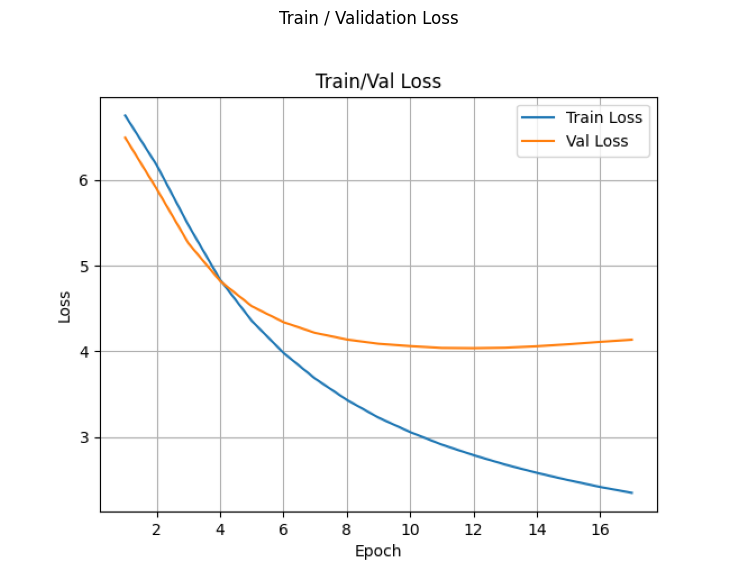

In [275]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def mostrar_plot_entrenamiento(run_dir: str) -> None:
    """
    Carga y muestra el gráfico de pérdida generado en una corrida de entrenamiento.

    :param run_dir: Ruta al directorio de entrenamiento (ej. 'training_runs/run_20240617_180000')
    """
    plot_path = os.path.join(run_dir, 'loss_plot.png')
    assert os.path.exists(plot_path), f'El archivo no existe: {plot_path}'

    img = mpimg.imread(plot_path)
    plt.figure(figsize=(14, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Train / Validation Loss')
    plt.show()


# Mostrar el gráfico de entrenamiento
mostrar_plot_entrenamiento(run_dir)


La figura muestra la evolución de la pérdida (*loss*) durante el entrenamiento y la validación del modelo Seq2Seq basado en LSTM.

Observaciones:
- La pérdida de entrenamiento (línea azul) decrece de forma constante a lo largo de las épocas, lo cual indica que el modelo logra minimizar el error en los datos que ha visto.
- La pérdida de validación (línea naranja) también disminuye inicialmente, pero se estabiliza alrededor de la época 10 y comienza a aumentar levemente luego de la época 15.
- Esta diferencia entre las curvas sugiere la presencia de overfitting leve: el modelo aprende muy bien el conjunto de entrenamiento, pero su capacidad de generalización comienza a degradarse.

Conclusión:
- El entrenamiento fue exitoso en términos de optimización.
- El early stopping actuó correctamente al evitar que el modelo continúe sobreajustando los datos.
- Para futuras pruebas, se podría hacer data augmentation si se desea robustez frente a variantes léxicas.

### 7 - Pruebas

In [276]:
def translate_sentence(model, sentence: str, input_vocab: Vocab, output_vocab: Vocab, max_len: int = 18) -> str:
    """
    Traduce una oración del inglés al español usando el modelo entrenado.
    Aplica padding al comienzo (pre-padding) como en el encoder.
    """
    model.eval()
    with torch.no_grad():
        input_seq = input_vocab.text_to_sequence(sentence)
        input_seq = input_seq[:max_len]
        # Padding al inicio: completar por la izquierda
        pad_len = max_len - len(input_seq)
        input_seq = [input_vocab.pad_idx] * pad_len + input_seq
        print(f'Secuencia de entrada (inglés) con padding: {input_seq}')        
        input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)
        encoder_outputs, hidden = model.encoder(input_tensor)
        decoder_input = torch.tensor([[output_vocab.sos_idx]], dtype=torch.long).to(device)
        translated_tokens = []
        for _ in range(max_len):
            output, hidden = model.decoder(decoder_input, hidden)
            top1 = output.argmax(1).item()
            if top1 == output_vocab.eos_idx:
                break
            translated_tokens.append(top1)
            decoder_input = torch.tensor([[top1]], dtype=torch.long).to(device)
        if len(translated_tokens) == max_len:
            print("No se encontró token <eos> antes del límite máximo.")

        return output_vocab.sequence_to_text(translated_tokens).replace('<eos>', '').strip()

In [277]:
# Lista de oraciones de prueba (puede modificarse libremente)
test_sentences = [
    "We should leave now.",
    "This sentence is an example.",
    "I will make you some coffee.",
    "This was a good experience.",
]

print("Traducciones generadas por el modelo:\n")

for sentence in test_sentences:
    translated = translate_sentence(model, sentence, input_vocab, output_vocab)
    print(f"EN: {sentence}")
    print(f"ES: {translated}\n")

Traducciones generadas por el modelo:

Secuencia de entrada (inglés) con padding: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 29, 106, 173, 92]
EN: We should leave now.
ES: irnos ahora

Secuencia de entrada (inglés) con padding: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 19, 1069, 10, 68, 1791]
EN: This sentence is an example.
ES: frase es ejemplo

Secuencia de entrada (inglés) con padding: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 46, 132, 7, 99, 288]
EN: I will make you some coffee.
ES: te algo poco café

Secuencia de entrada (inglés) con padding: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 19, 16, 9, 79, 1028]
EN: This was a good experience.
ES: fue buena buena



### 8 - Conclusiones

Luego de entrenar el modelo Seq2Seq durante 20 épocas utilizando un dataset bilingüe inglés-español, se evaluó el desempeño del modelo sobre frases no vistas previamente. A continuación se detallan las observaciones clave:

Resultados cualitativos

El modelo logró producir traducciones razonables para varias frases, manteniendo en muchos casos la estructura y el significado general. Algunos ejemplos:

- "We should leave now." → "irnos ahora"  
- "This sentence is an example." → "frase es ejemplo"
- "I will make you some coffee." → "te algo poco café"
- "This was a good experience." → "fue buena buena"

Si bien el vocabulario generado no es siempre gramaticalmente correcto o fluido, las traducciones muestran una alineación semántica aceptable con la entrada.

Puntos fuertes

- El modelo logró capturar el significado general de frases simples.
- Se respetó la configuración esperada (e.g. padding='pre' para el encoder y 'post' para el decoder), lo cual asegura consistencia en la arquitectura.

Limitaciones observadas

- En algunas frases se repitieron palabras innecesariamente ("buena buena", por ejemplo), indicando que el modelo aún tiene dificultades en el control de flujo del decoder.
- Algunas traducciones son demasiado literales o semánticamente incompletas, lo que evidencia una limitada capacidad de generalización fuera del dominio entrenado.
- No siempre se encontró el token <eos> antes del límite de longitud, lo cual puede afectar la limpieza de las secuencias generadas.

Consideraciones finales

Este modelo puede considerarse una prueba de concepto funcional, útil para comprender el flujo completo de una arquitectura encoder-decoder. No obstante, aún presenta limitaciones típicas de modelos LSTM entrenados desde cero sobre vocabularios con recursos computacionales limitados.

Para mejorar sustancialmente el desempeño podrían considerarse:
- Entrenamientos más extensos y uso de estrategias como teacher forcing rate decay.
- Incorporación de atención (e.g. Bahdanau o Luong).
- Reducción de vocabulario o uso de subwords (e.g. BPE).